In [1]:
from datasets import load_dataset


# Data Collection

## Data Candidates

https://huggingface.co/datasets/Enlightir/ai-vs-human-combined

+ (+) Most recently updated
+ (+) \> 500,000 entries
- (-) Author page/site is relatively blank or un-informative
- (-) No `readme` on data sources or verification of AI/human source

https://huggingface.co/datasets/Samambas/Human_vs_AI_Portuguese

+ (+) Foreign language, good to test with later
- (-) Same issues as above

https://huggingface.co/datasets/ahmadreza13/human-vs-Ai-generated-dataset

+ (+) Labels my model generated with
- (-) Similar data sourcing issues

https://huggingface.co/datasets/ilyasoulk/ai-vs-human-meta-llama-Llama-3.1-8B-Instruct-CNN / https://huggingface.co/datasets/zcamz/ai-vs-human-google-gemma-2-2b-it

+ (-) Datasets with specific models, good for later comparisons 
- (-) Relatively smaller

---

I think for now it's best to move forward with the `ahmadreza13/human-vs-Ai-generated-dataset` dataset - it's good that it labels by model, but it seems like mostly wikipedia. That might cause issues! But if those pop up in testing, come back here and change the tuning dataset!

In [2]:

dataset = load_dataset("ahmadreza13/human-vs-Ai-generated-dataset")

In [3]:
print("Models/sources:", set(dataset['train']['model'][:]))

Models/sources: {'wikipedia', 'Claude3-Opus', 'gemini-1.5-pro', 'claude', 'GPT4'}


## Data Exploration

In [4]:
print("Shape of training dataset:", dataset['train'].shape)


Shape of training dataset: (3614247, 3)


In [5]:
dataset['train'].column_names

['data', 'generated', 'model']

In [6]:
dataset = dataset.rename_column('generated', 'labels')
dataset = dataset["train"].train_test_split(test_size=0.1, seed=42)
dataset

DatasetDict({
    train: Dataset({
        features: ['data', 'labels', 'model'],
        num_rows: 3252822
    })
    test: Dataset({
        features: ['data', 'labels', 'model'],
        num_rows: 361425
    })
})

<Axes: >

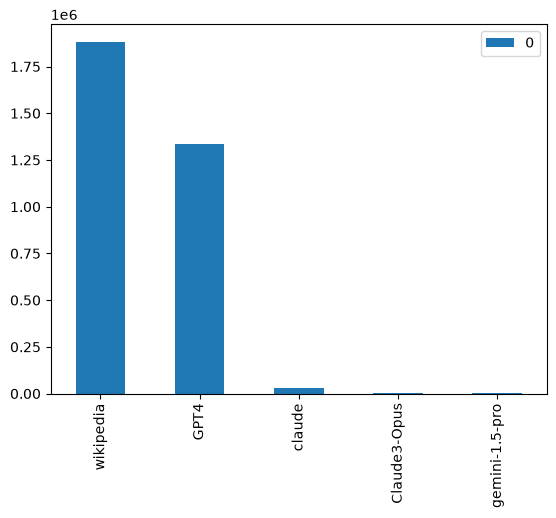

In [7]:
import pandas
from collections import Counter

# plot a distribution of the number of counts of each source in the dataset

df = pandas.DataFrame.from_dict(Counter(dataset['train']['model'][:]), orient='index')
df.plot(kind='bar')


<Axes: >

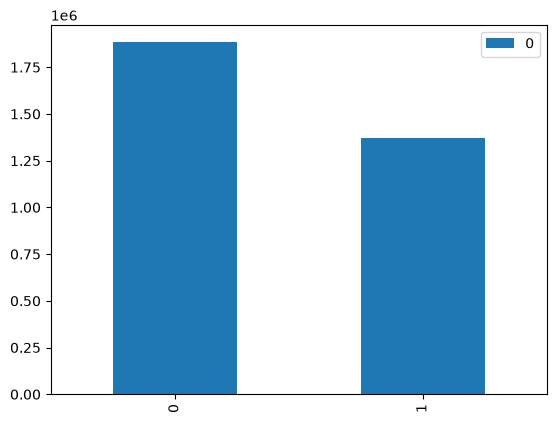

In [9]:
# now check total no. of generated vs human data

df = pandas.DataFrame.from_dict(Counter(dataset['train']['labels'][:]), orient='index')
df.plot(kind='bar')


In [10]:
# try checking, e.g., all wikipedia data is human. first, filter: 

temp = dataset['train']
temp = temp.filter(lambda example: example['model'] == 'wikipedia')

Filter:   0%|          | 0/3252822 [00:00<?, ? examples/s]

<Axes: >

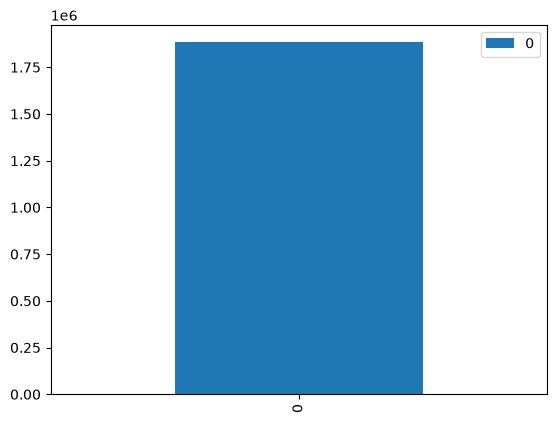

In [12]:
# then count and plot

temp = temp['labels'][:]
counts = Counter(temp)

df = pandas.DataFrame.from_dict(counts, orient='index')
df.plot(kind='bar')


In [13]:
# testing if counter works without slicing the dataset and loading all into mem
Counter(dataset['train']['model'])

Counter({'wikipedia': 1883392,
         'GPT4': 1335771,
         'claude': 28972,
         'Claude3-Opus': 3778,
         'gemini-1.5-pro': 909})

In [14]:
# try with pandas instead; faster!
dataset['train'].remove_columns('data').to_pandas().value_counts()

labels  model         
0       wikipedia         1883392
1       GPT4              1335771
        claude              28972
        Claude3-Opus         3778
        gemini-1.5-pro        909
Name: count, dtype: int64

In [15]:
# check features
dataset['train'].features

{'data': Value('string'), 'labels': Value('int64'), 'model': Value('string')}

In [16]:
# now just get a final no. of human vs ai to compare to
generated_counts = dataset['train'].remove_columns(['data', 'model']).to_pandas().value_counts()
generated_counts

labels
0         1883392
1         1369430
Name: count, dtype: int64

In [17]:
human_counts, ai_counts = generated_counts[0], generated_counts[1]
percentage_human = human_counts / (human_counts + ai_counts) * 100
print(f"Percentage of human data: {percentage_human:.2f}%")

Percentage of human data: 57.90%


# Tokenising

In [18]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased")

def preprocess_function(examples):
    tokenized = tokenizer(examples["data"], truncation=False)
    return {"token_length": [len(ids) for ids in tokenized["input_ids"]]}

tokenized_dataset = dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/3252822 [00:00<?, ? examples/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (626 > 512). Running this sequence through the model will result in indexing errors


Map:   0%|          | 0/361425 [00:00<?, ? examples/s]

In [19]:
lengths = tokenized_dataset['train'].remove_columns(['data', 'model', 'labels']).to_pandas()

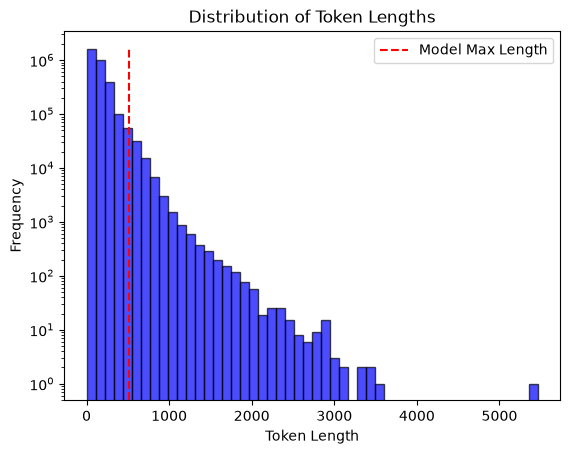

In [20]:
import matplotlib.pyplot as plt
plt.hist(lengths['token_length'], bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.vlines([tokenizer.model_max_length], ymin=0, ymax=plt.ylim()[1], colors='r', linestyles='dashed', label='Model Max Length')

plt.yscale('log')

plt.xlabel('Token Length')
plt.ylabel('Frequency')

plt.title('Distribution of Token Lengths')

plt.legend()
plt.show()

In [21]:
(lengths["token_length"] > tokenizer.model_max_length).mean()

np.float64(0.023285319639377747)

In [22]:
def token_length_analysis(tokenized_dataset, filter_model=None):
    if filter_model:
        tokenized_dataset = tokenized_dataset.filter(lambda x: x['model'] == filter_model)

    lengths = tokenized_dataset['train'].remove_columns(['data', 'model', 'labels']).to_pandas()
    
    plt.hist(lengths['token_length'], bins=50, alpha=0.7, color='blue', edgecolor='black')
    plt.vlines([tokenizer.model_max_length], ymin=0, ymax=plt.ylim()[1], colors='r', linestyles='dashed', label='Model Max Length')

    plt.yscale('log')

    plt.xlabel('Token Length')
    plt.ylabel('Frequency')

    plt.title('Distribution of Token Lengths')

    plt.legend()
    plt.show()

    print(f"Percentage of samples exceeding model max length: {(lengths['token_length'] > tokenizer.model_max_length).mean() * 100:.2f}%")  


Filter:   0%|          | 0/3252822 [00:00<?, ? examples/s]

Filter:   0%|          | 0/361425 [00:00<?, ? examples/s]

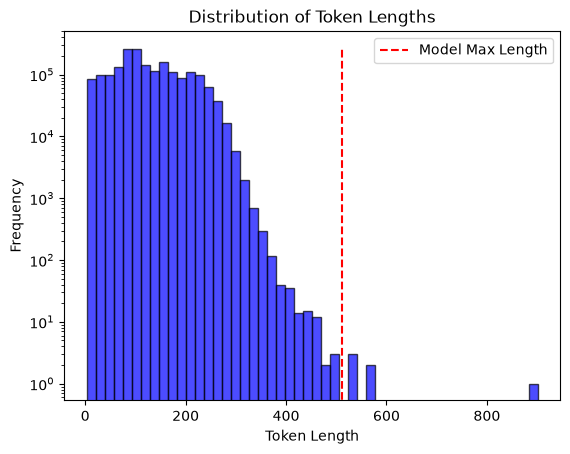

Percentage of samples exceeding model max length: 0.00%


In [23]:
token_length_analysis(tokenized_dataset, filter_model='wikipedia')

Filter:   0%|          | 0/3252822 [00:00<?, ? examples/s]

Filter:   0%|          | 0/361425 [00:00<?, ? examples/s]

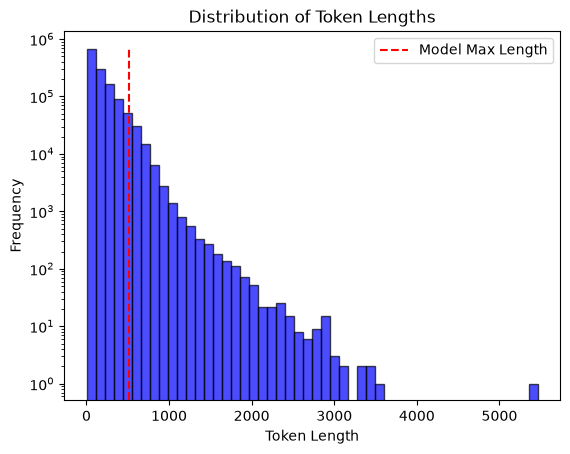

Percentage of samples exceeding model max length: 5.45%


In [24]:
token_length_analysis(tokenized_dataset, filter_model='GPT4')

Filter:   0%|          | 0/3252822 [00:00<?, ? examples/s]

Filter:   0%|          | 0/361425 [00:00<?, ? examples/s]

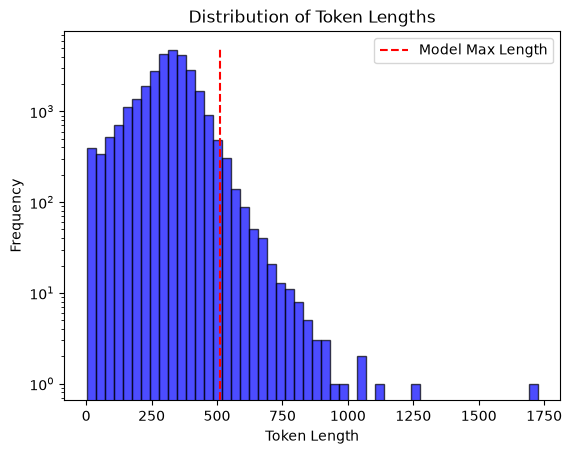

Percentage of samples exceeding model max length: 2.62%


In [25]:
token_length_analysis(tokenized_dataset, filter_model='claude')

Filter:   0%|          | 0/3252822 [00:00<?, ? examples/s]

Filter:   0%|          | 0/361425 [00:00<?, ? examples/s]

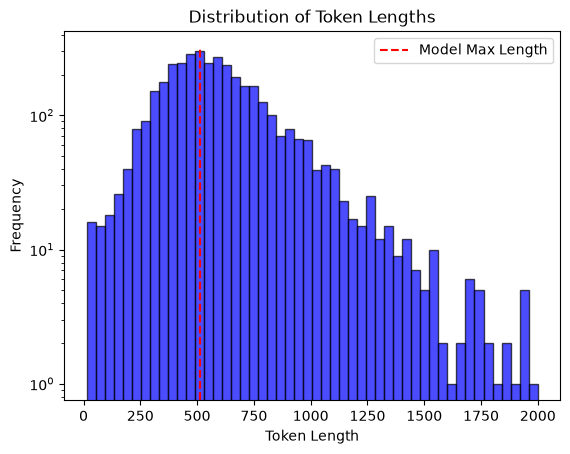

Percentage of samples exceeding model max length: 58.95%


In [26]:
token_length_analysis(tokenized_dataset, filter_model='Claude3-Opus')

Filter:   0%|          | 0/3252822 [00:00<?, ? examples/s]

Filter:   0%|          | 0/361425 [00:00<?, ? examples/s]

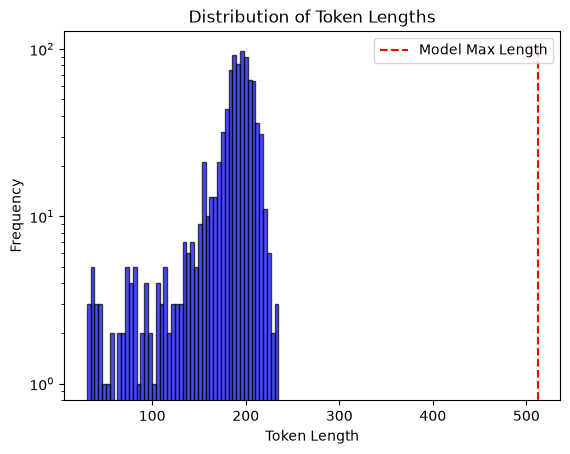

Percentage of samples exceeding model max length: 0.00%


In [27]:
token_length_analysis(tokenized_dataset, filter_model='gemini-1.5-pro')

## Notes

AI data skews longer. If having issues, maybe try cutting length earlier (eg 256). Then, the AI flag goes from 'super long text' to 'more likely to be at 256/semantically cut-off suddently' rather than just length itself. 

In [28]:
def preprocess_function(examples):
    return tokenizer(examples["data"], truncation=True)

tokenized_dataset = dataset.map(preprocess_function, batched=True)

from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/3252822 [00:00<?, ? examples/s]

Map:   0%|          | 0/361425 [00:00<?, ? examples/s]

# Performance Metrics

In [29]:
import evaluate

accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

import numpy as np
from sklearn.metrics import confusion_matrix

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    tn, fp, fn, tp = confusion_matrix(labels, predictions).ravel()   

    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)

    accuracy_score = accuracy.compute(predictions=predictions, references=labels)["accuracy"] 
    f1_score = f1.compute(predictions=predictions, references=labels)["f1"]
    return {
        "accuracy": accuracy_score, 
        "f1": f1_score,
        "fpr" : fpr,
        "fnr" : fnr
        }


In [30]:
id2label = {0: "HUMAN", 1: "AI"}
label2id = {"HUMAN": 0, "AI": 1}

# Training

In [31]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert/distilbert-base-uncased", num_labels=2, id2label=id2label, label2id=label2id
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [32]:
training_args = TrainingArguments(
    output_dir="my_awesome_model",
    learning_rate=2e-5,
    per_device_train_batch_size=16, # can push higher w/ GPU vs mba's cpu
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    push_to_hub=False,
    fp16=True, # use GPU
)

trainer = Trainer(
    model=model,
    args=training_args,
    #train_dataset=tokenized_dataset["train"],
    train_dataset=tokenized_dataset["train"].shuffle(seed=42).select(range(50000)),
    #eval_dataset=tokenized_dataset["test"],
    eval_dataset=tokenized_dataset["test"].shuffle(seed=42).select(range(5000)),
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Fpr,Fnr
1,0.010565,0.005222,0.999000,0.998828,0.001046,0.000938


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3125, training_loss=0.025633332958221434, metrics={'train_runtime': 206.7796, 'train_samples_per_second': 241.803, 'train_steps_per_second': 15.113, 'total_flos': 5146805515256064.0, 'train_loss': 0.025633332958221434, 'epoch': 1.0})